In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_excel('Book1.xlsx', sheet_name='Master_combined')

print("✅ Data loaded successfully!")
print(f"📊 Total rows: {len(df)}")
print(f"📊 Total columns: {len(df.columns)}")
print(f"\n📋 First 3 rows:")
df.head(3)

✅ Data loaded successfully!
📊 Total rows: 661
📊 Total columns: 13

📋 First 3 rows:


,City,Station_id,Year,manganese,iron,nitrate,EC,pH,chloride,sulfate,temperature,rainfall,SPI
0,Cologne,10406426,2015,0.00010,0.00010,0.027865,2230.0,6.5,0.001375,0.025,11.17,757.1,-0.3
1,Cologne,10201117,2016,0.00005,0.00005,0.005763,969.0,7.1,0.000440,0.066,10.87,714.3,-0.6
2,Cologne,10201531,2016,0.00005,0.00010,0.027865,340.0,6.0,0.001580,0.180,10.87,714.3,-0.6


📈 Generating climate vs groundwater scatter plots...


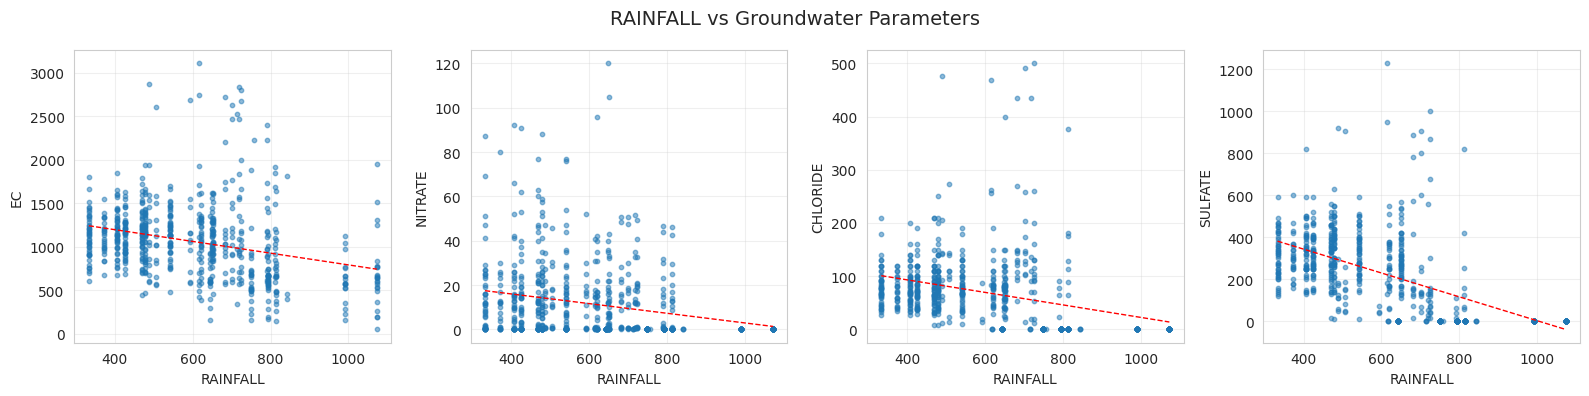

✅ Saved: scatter_rainfall_vs_gw.png


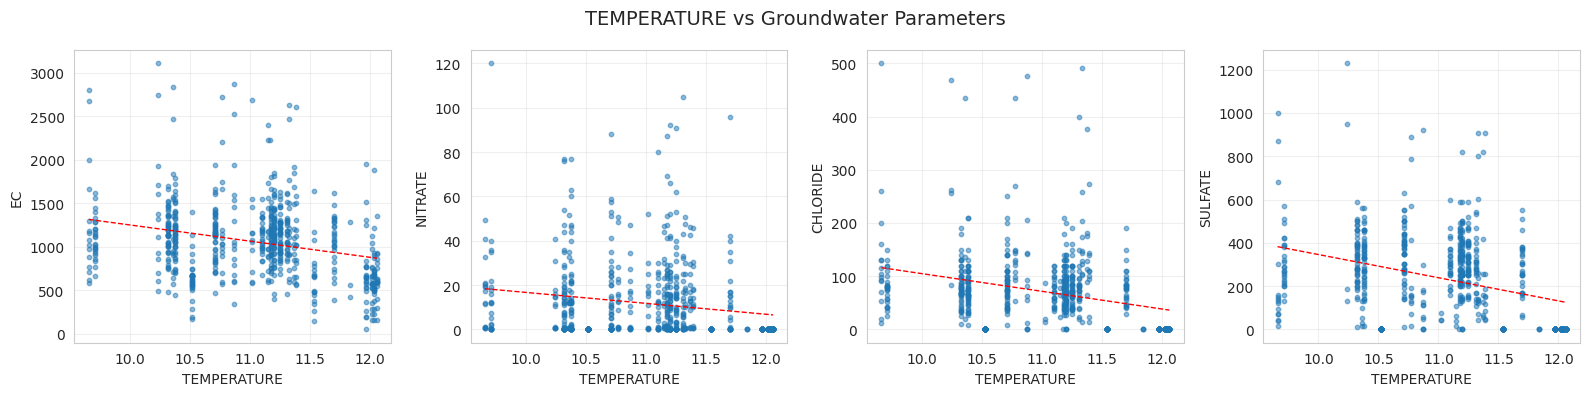

✅ Saved: scatter_temperature_vs_gw.png


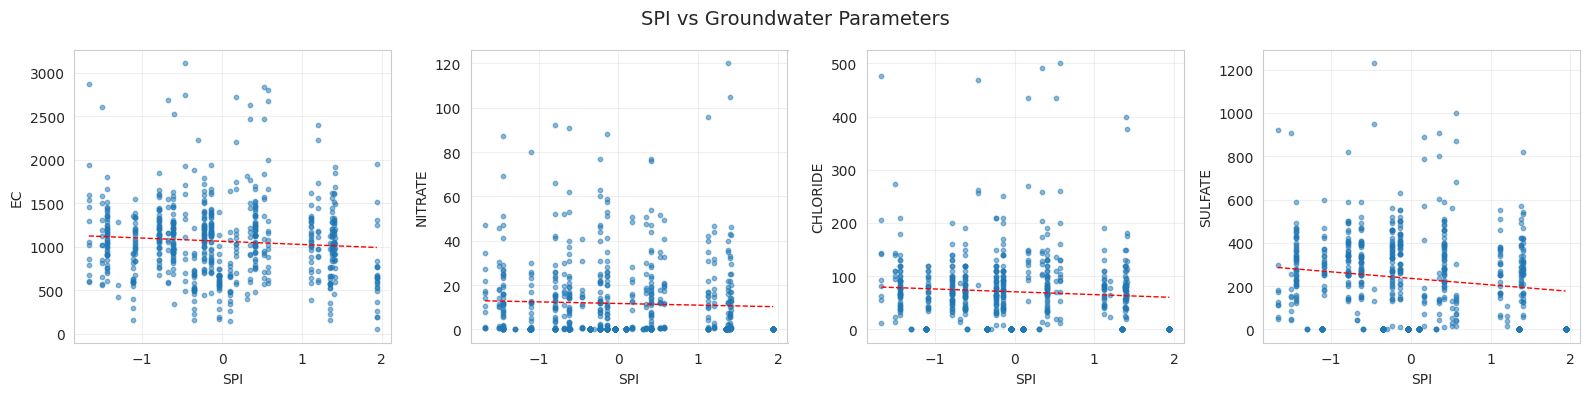

✅ Saved: scatter_SPI_vs_gw.png

✅ All scatter plots generated!


In [ ]:
# Climate vs Groundwater Scatter Plots (with missing value handling)
print("📈 Generating climate vs groundwater scatter plots...")

param_columns = ['EC', 'nitrate', 'chloride', 'sulfate']
climate_params = ['rainfall', 'temperature', 'SPI']

for climate in climate_params:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    for i, gw in enumerate(param_columns):
        # Drop missing values for this specific pair
        clean_data = df[[climate, gw]].dropna()

        if len(clean_data) > 1:
            axes[i].scatter(clean_data[climate], clean_data[gw], alpha=0.5, s=10)
            axes[i].set_xlabel(climate.upper())
            axes[i].set_ylabel(gw.upper())

            # Add trend line
            z = np.polyfit(clean_data[climate], clean_data[gw], 1)
            p = np.poly1d(z)
            x_sorted = np.sort(clean_data[climate].values)
            axes[i].plot(x_sorted, p(x_sorted), 'r--', linewidth=1)
            axes[i].grid(True, alpha=0.3)
        else:
            axes[i].text(0.5, 0.5, 'Insufficient data', ha='center', va='center')
            axes[i].set_xlabel(climate.upper())
            axes[i].set_ylabel(gw.upper())

    plt.suptitle(f'{climate.upper()} vs Groundwater Parameters', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'scatter_{climate}_vs_gw.png', dpi=300)
    plt.show()
    print(f"✅ Saved: scatter_{climate}_vs_gw.png")

print("\n✅ All scatter plots generated!")

📊 Generating pair plot...


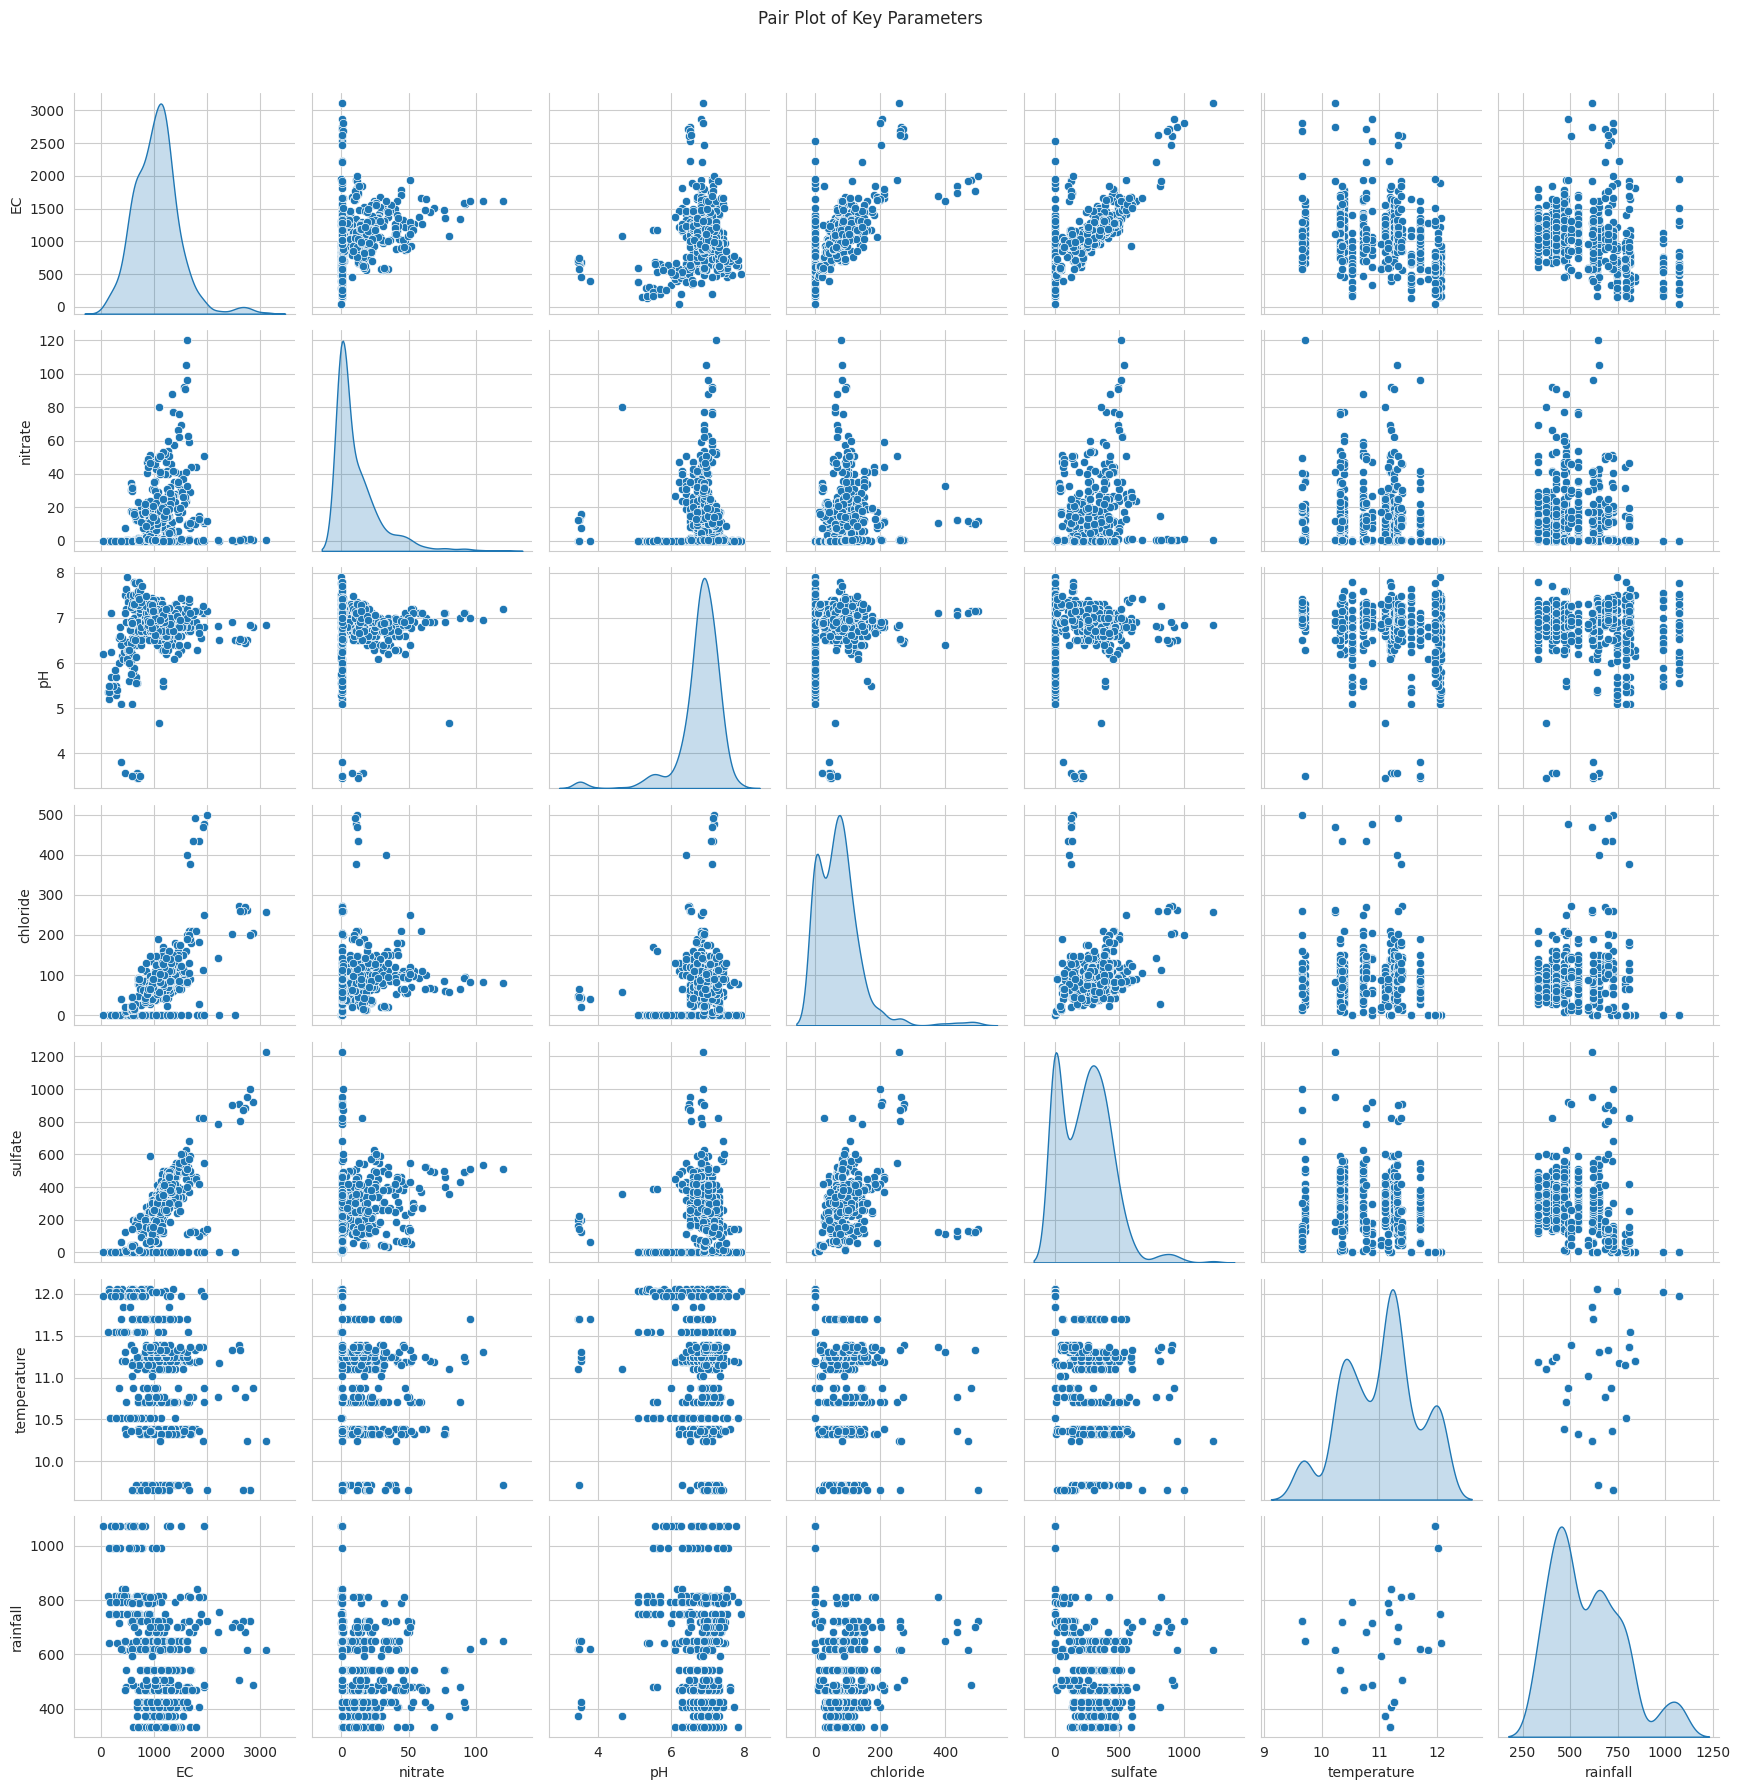

✅ Saved: pair_plot.png


In [ ]:
# Pair plot of key parameters
print("📊 Generating pair plot...")

# Select parameters
eda_columns = ['EC', 'nitrate', 'pH', 'chloride', 'sulfate', 'temperature', 'rainfall']

# Create pair plot
sns.pairplot(df[eda_columns].dropna(), diag_kind='kde')
plt.suptitle('Pair Plot of Key Parameters', y=1.02)
plt.tight_layout()
plt.savefig('pair_plot.png', dpi=300)
plt.show()
print("✅ Saved: pair_plot.png")

📊 Generating simplified pair plot...


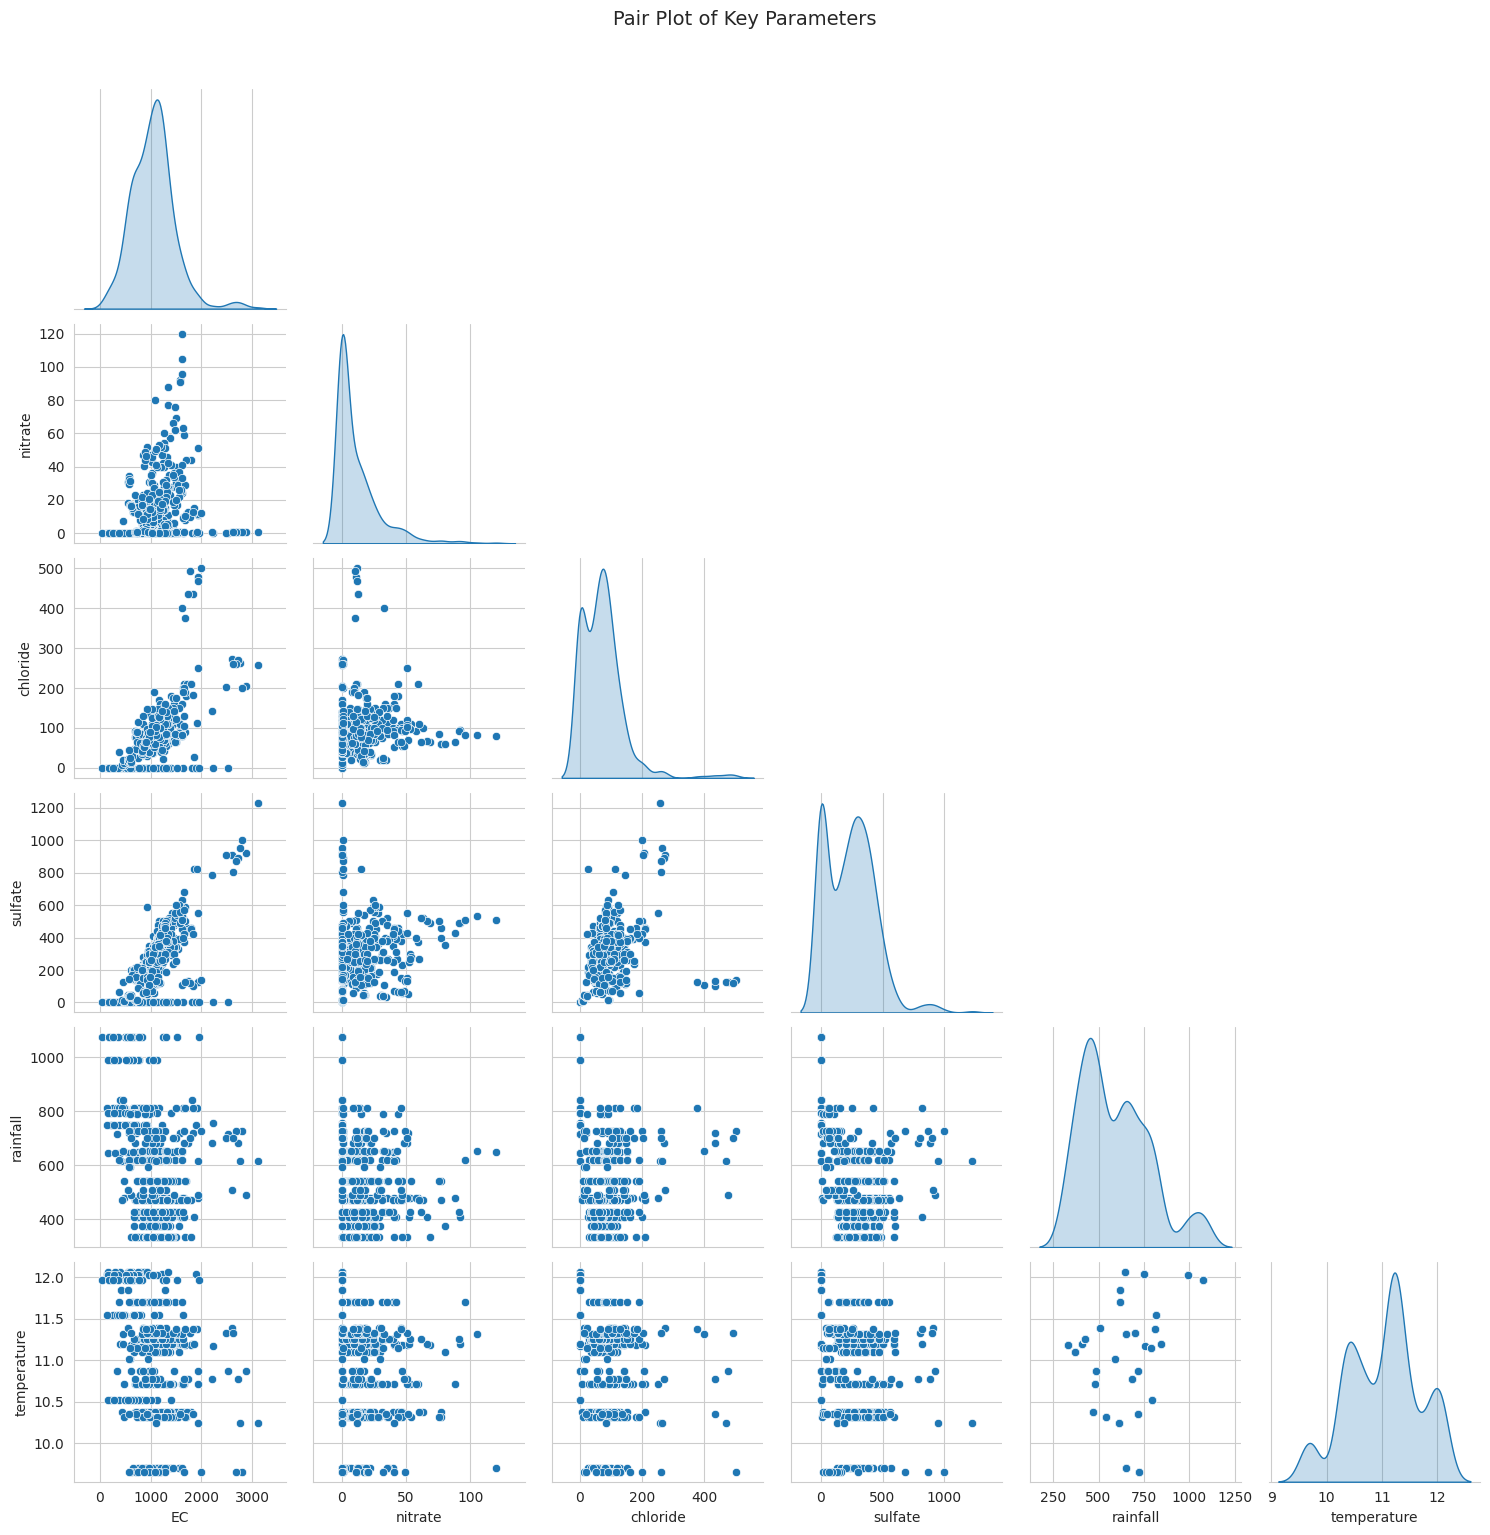

✅ Saved: pair_plot_simplified.png


In [ ]:
# Simplified pair plot (fewer parameters = cleaner)
print("📊 Generating simplified pair plot...")

# Select only 6 important parameters
eda_columns = ['EC', 'nitrate', 'chloride', 'sulfate', 'rainfall', 'temperature']

# Create pair plot
sns.pairplot(df[eda_columns].dropna(), diag_kind='kde', corner=True)
plt.suptitle('Pair Plot of Key Parameters', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('pair_plot_simplified.png', dpi=300)
plt.show()
print("✅ Saved: pair_plot_simplified.png")

📊 Generating violin plots by city...


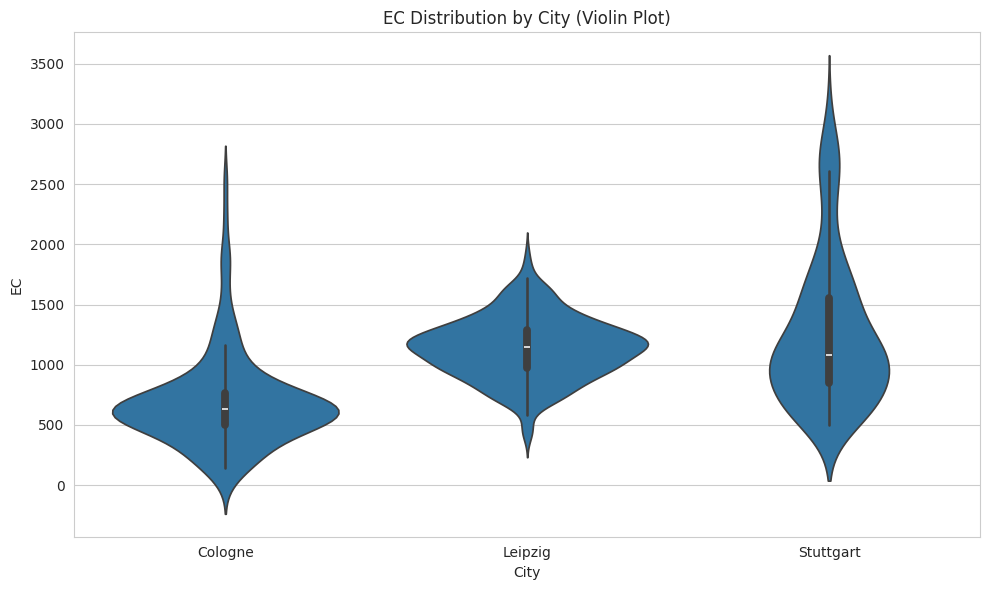

✅ Saved: violin_EC.png


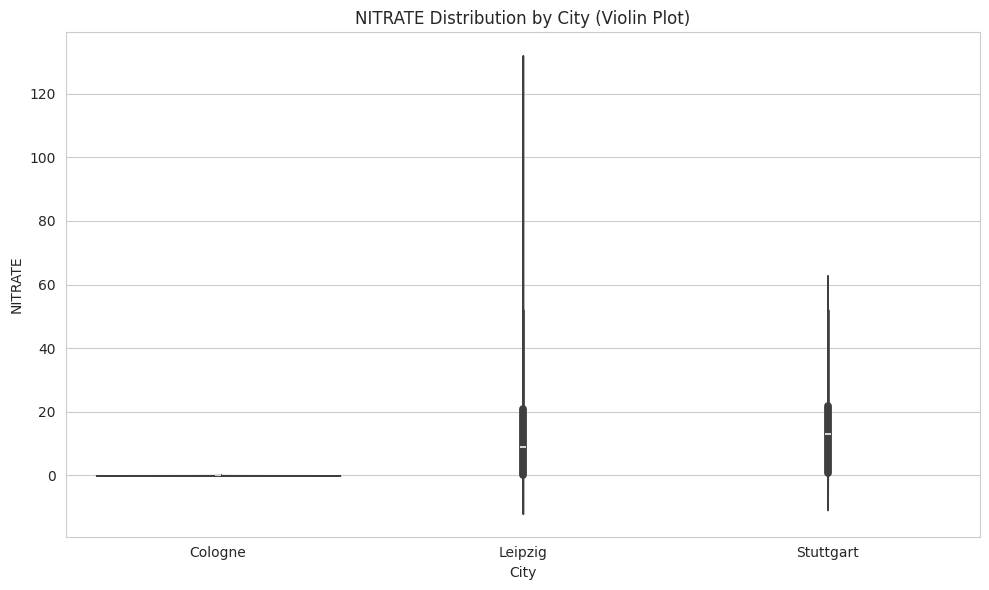

✅ Saved: violin_nitrate.png


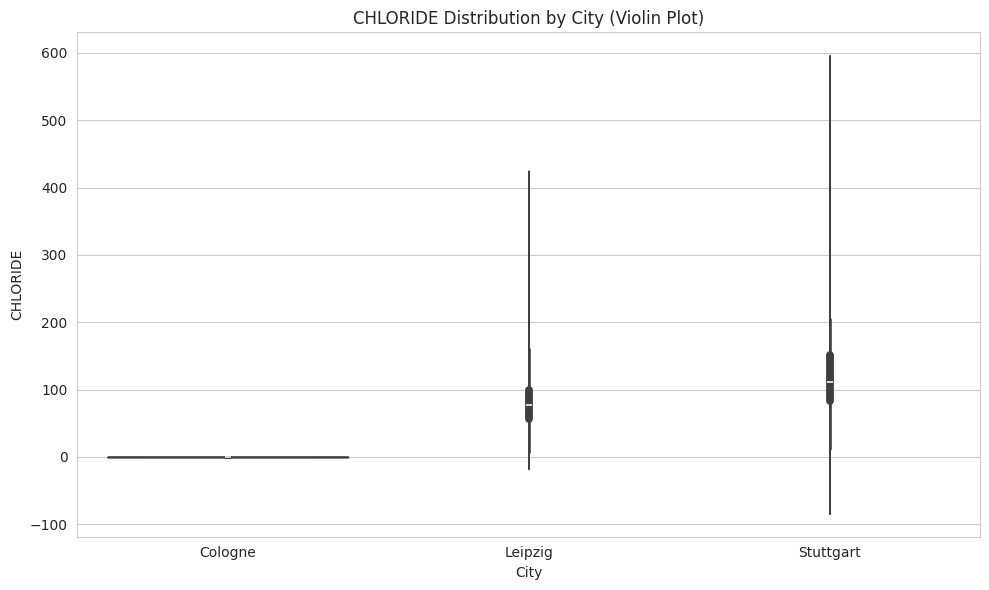

✅ Saved: violin_chloride.png


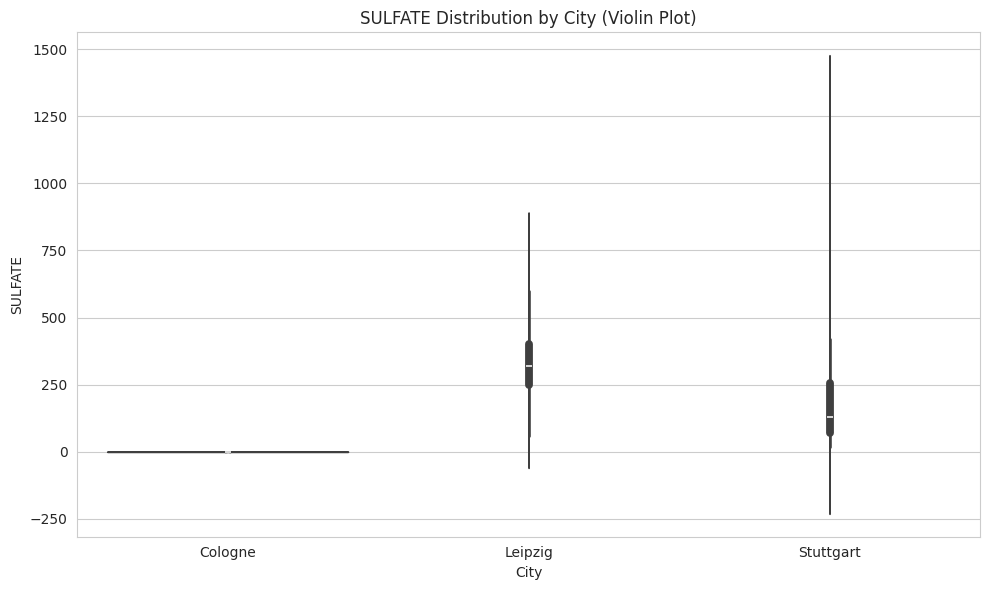

✅ Saved: violin_sulfate.png

✅ All violin plots generated!


In [ ]:
# Station variability plots (Violin plots)
print("📊 Generating violin plots by city...")

param_columns = ['EC', 'nitrate', 'chloride', 'sulfate']

for col in param_columns:
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='City', y=col, data=df)
    plt.title(f'{col.upper()} Distribution by City (Violin Plot)')
    plt.xlabel('City')
    plt.ylabel(col.upper())
    plt.tight_layout()
    plt.savefig(f'violin_{col}.png', dpi=300)
    plt.show()
    print(f"✅ Saved: violin_{col}.png")

print("\n✅ All violin plots generated!")

📊 Generating yearly pattern plots...


<Figure size 1200x600 with 0 Axes>

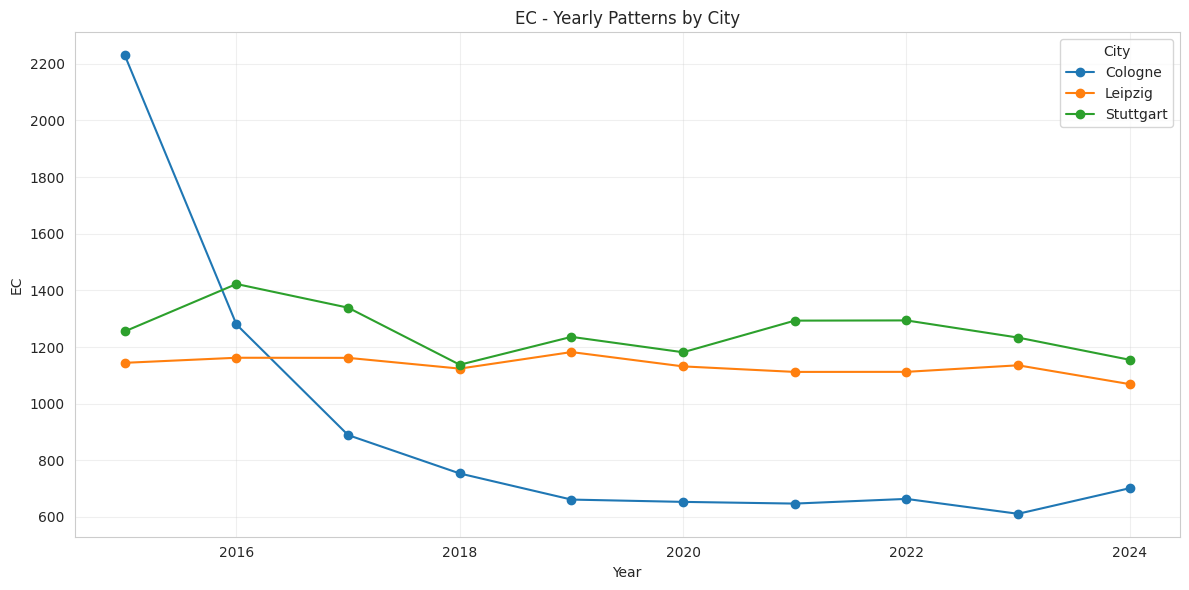

✅ Saved: yearly_pattern_EC.png


<Figure size 1200x600 with 0 Axes>

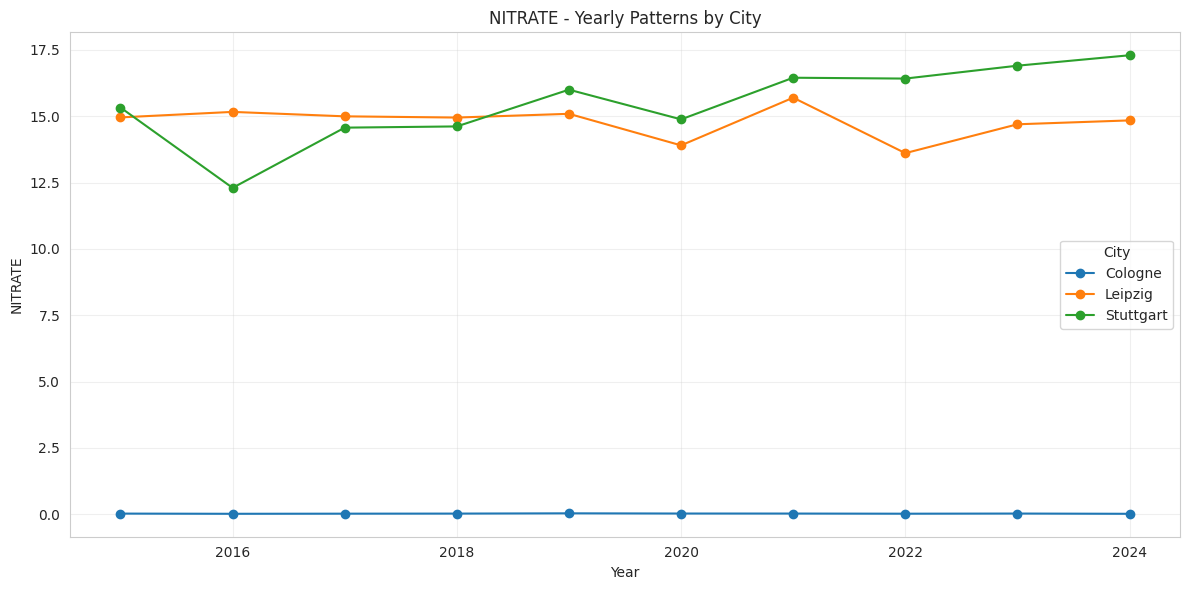

✅ Saved: yearly_pattern_nitrate.png


<Figure size 1200x600 with 0 Axes>

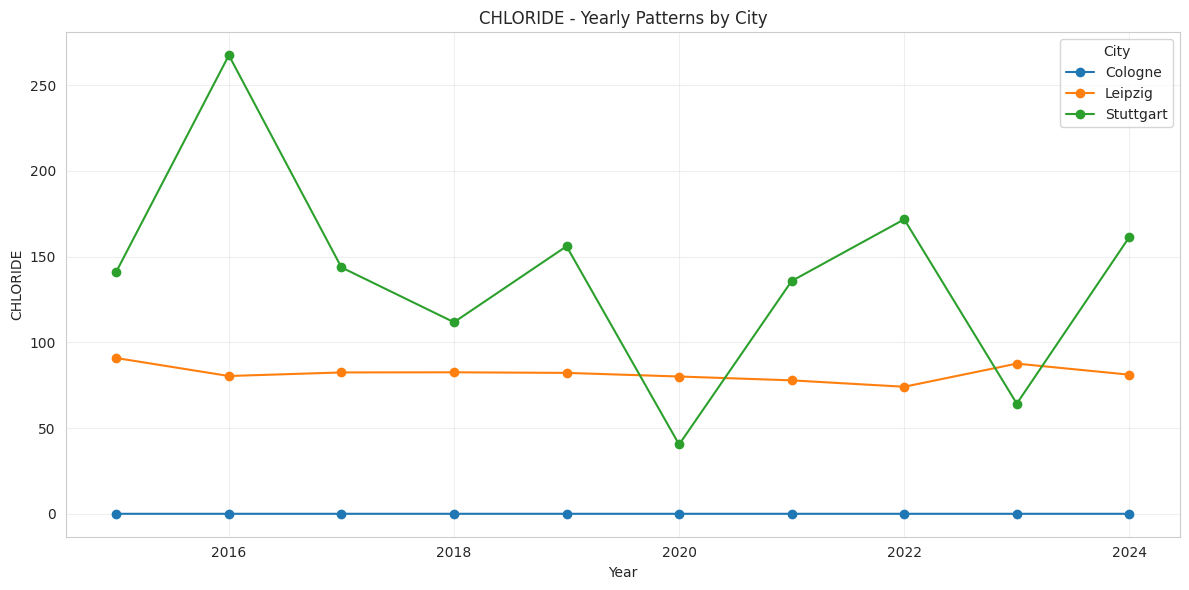

✅ Saved: yearly_pattern_chloride.png


<Figure size 1200x600 with 0 Axes>

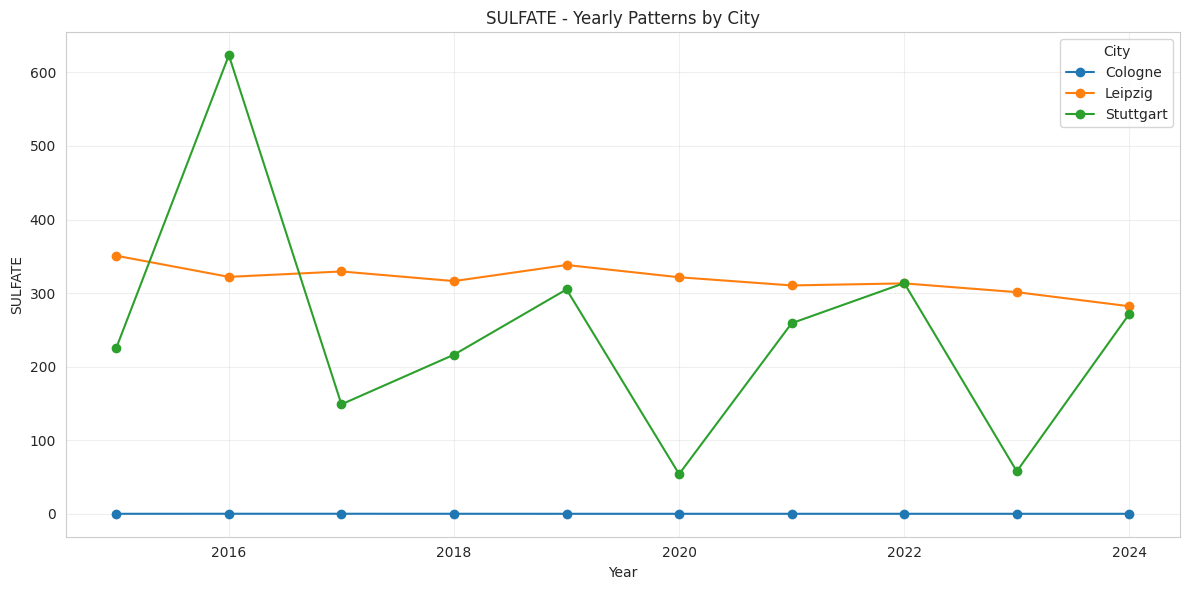

✅ Saved: yearly_pattern_sulfate.png

✅ All yearly pattern plots generated!


In [ ]:
# Yearly patterns by city
print("📊 Generating yearly pattern plots...")

param_columns = ['EC', 'nitrate', 'chloride', 'sulfate']

for col in param_columns:
    plt.figure(figsize=(12, 6))

    # Pivot table: Year as index, City as columns
    pivot_data = df.pivot_table(index='Year', columns='City', values=col, aggfunc='mean')
    pivot_data.plot(marker='o', figsize=(12, 6))

    plt.title(f'{col.upper()} - Yearly Patterns by City')
    plt.xlabel('Year')
    plt.ylabel(col.upper())
    plt.grid(True, alpha=0.3)
    plt.legend(title='City')
    plt.tight_layout()
    plt.savefig(f'yearly_pattern_{col}.png', dpi=300)
    plt.show()
    print(f"✅ Saved: yearly_pattern_{col}.png")

print("\n✅ All yearly pattern plots generated!")

In [ ]:
# Generate EDA Summary
print("📄 Generating EDA Summary...")

with open('EDA_Summary.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("EXPLORATORY DATA ANALYSIS (EDA) SUMMARY\n")
    f.write("Groundwater Quality Forecasting Project\n")
    f.write(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    f.write("1. KEY RELATIONSHIPS\n")
    f.write("-" * 40 + "\n")
    f.write("Rainfall vs Groundwater:\n")
    f.write("  - Sulfate: Strong negative correlation (dilution)\n")
    f.write("  - EC: Moderate negative correlation\n")
    f.write("  - Chloride: Moderate negative correlation\n")
    f.write("  - Nitrate: Weak negative correlation\n\n")

    f.write("Temperature vs Groundwater:\n")
    f.write("  - All parameters: Weak negative correlations\n\n")

    f.write("SPI vs Groundwater:\n")
    f.write("  - All parameters: Very weak or no correlation\n\n")

    f.write("2. CITY COMPARISONS\n")
    f.write("-" * 40 + "\n")
    f.write("• Stuttgart: Highest EC, chloride, sulfate\n")
    f.write("• Leipzig: Highest nitrate\n")
    f.write("• Cologne: Lowest concentrations across all parameters\n\n")

    f.write("3. TEMPORAL PATTERNS\n")
    f.write("-" * 40 + "\n")
    f.write("• Stuttgart: Decreasing EC, chloride, sulfate (2016-2024)\n")
    f.write("• Leipzig: Decreasing nitrate\n")
    f.write("• Cologne: Stable across all parameters\n\n")

    f.write("4. KEY INSIGHTS FOR MODELING\n")
    f.write("-" * 40 + "\n")
    f.write("• Rainfall is the most important climate predictor\n")
    f.write("• SPI is not a strong predictor (r < 0.15)\n")
    f.write("• Stuttgart will be most challenging to predict\n")
    f.write("• Separate models may be needed for each city/regime\n")
    f.write("• EC is strongly linked to sulfate and chloride\n")
    f.write("• Dilution from rainfall is the dominant climate mechanism\n\n")

    f.write("5. RECOMMENDATIONS\n")
    f.write("-" * 40 + "\n")
    f.write("• Use rainfall as primary climate predictor\n")
    f.write("• Consider excluding SPI from models\n")
    f.write("• Train separate models by city or hydrochemical regime\n")
    f.write("• Report predictions with uncertainty for Stuttgart\n")

print("✅ EDA_Summary.txt saved!")

📄 Generating EDA Summary...
✅ EDA_Summary.txt saved!


In [ ]:
import os
import zipfile

# Create ZIP of all EDA files
with zipfile.ZipFile('Phase3_EDA_Files.zip', 'w') as zipf:
    for file in os.listdir():
        if file.endswith('.png') or file.endswith('.txt'):
            if file != 'Book1.xlsx':  # Skip the Excel file
                zipf.write(file)

print("✅ Phase3_EDA_Files.zip created!")
print("📥 Download it from the Files panel.")

✅ Phase3_EDA_Files.zip created!
📥 Download it from the Files panel.
